In [46]:
import numpy as np
from scipy.integrate import solve_ivp, odeint
import matplotlib.pyplot as plt

## Exercise 1 a) Mass balance and concentration balance

### General mole balance

We consider a batch reactor operating at constant volume.

The general mole balance for species *i* is:

$$
\frac{dN_i}{dt} = r_i V
$$

where:
- $N_i$ = number of moles of species *i*
- $r_i$ = rate of formation ($molL^{-1}$ $s^{-1}$)
- $V$ = reactor volume (constant)

---

### Transformation to concentration balance

Concentration is defined as:

$$
C_i = \frac{N_i}{V}
$$

Thus:

$$
N_i = C_i V
$$

Taking the time derivative:

$$
\frac{dN_i}{dt} = V \frac{dC_i}{dt}
$$

Substituting into the mole balance:

$$
V \frac{dC_i}{dt} = r_i V
$$

Since the volume is constant:

$$
\boxed{\frac{dC_i}{dt} = r_i}
$$

---

### Reaction mechanism

$$
E + S \xrightleftharpoons[k_{b}]{k_f} ES \xrightarrow{k_{cat}} E + P
$$

---

### Concentration balances

$$
\frac{d[S]}{dt} = -k_f[E][S] + k_{b}[ES]
$$

$$
\frac{d[E]}{dt} = -k_f[E][S] + (k_{b} + k_{cat})[ES]
$$

$$
\frac{d[ES]}{dt} = k_f[E][S] - (k_{b} + k_{cat})[ES]
$$

$$
\frac{d[P]}{dt} = k_{cat}[ES]
$$

---

### Conservation of mass

$$
[E]_0 = [E] + [ES]
$$

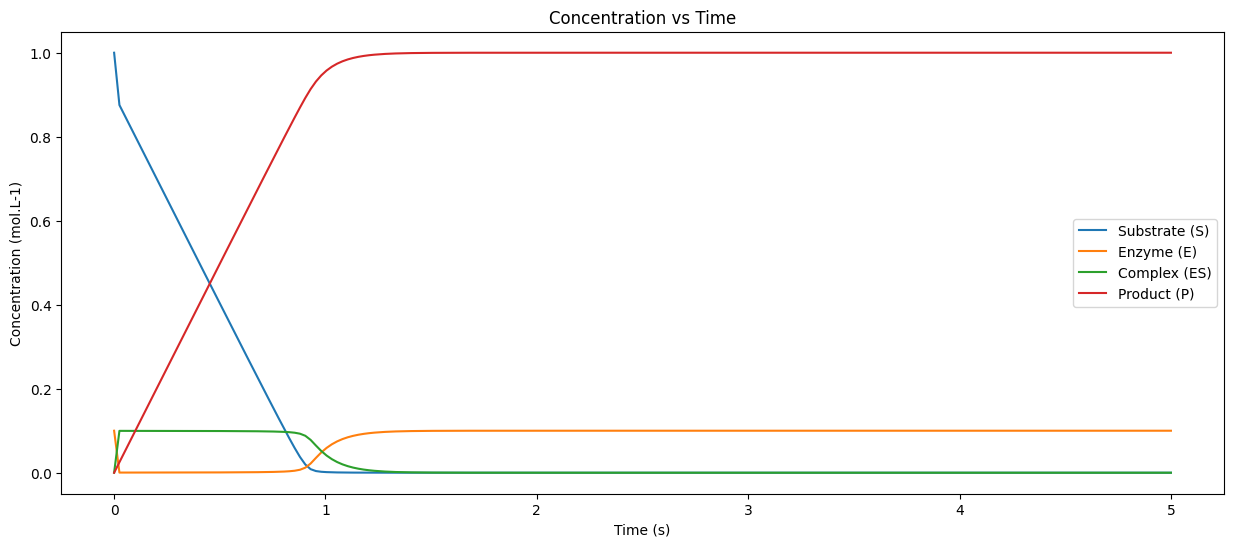

Conservation check: E_total.min() = 0.09999999999999981 , E_total.max() = 0.10000000000000017 , E0 = 0.1


In [47]:
#Exercice 1 b)Solve the ODE system

#parameters
kf = 1e4 #[L.mol-1.s-1]
kb = 20 #[s-1]
kcat = 10 #[s-1]

#initial conditions
S0 = 1 #[mol.L-1]
E0 = 0.1 #[mol.L-1]
ES0 = P0 = 0 #[mol.L-1]
y0 = [S0, E0, ES0, P0]

def mass_balance(t, y):
    S, E, ES, P = y
    dSdt = -kf * S * E + kb * ES
    dEdt = -kf * S * E + kb * ES + kcat * ES
    dESdt = kf * S * E - kb * ES - kcat * ES
    dPdt = kcat * ES
    return [dSdt, dEdt, dESdt, dPdt]

#time interval
t_span = (0, 5) # from 0 to 5 second
t_eval = np.linspace(0, 5, 200) 

#solve the ODE system
solution = solve_ivp(mass_balance, t_span, y0, t_eval=t_eval, method='RK45')
S, E, ES, P = solution.y
t = solution.t


#plotting the results
plt.figure(figsize=(15, 6))
plt.plot(t, S, t, E, t, ES, t, P)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol.L-1)')
plt.legend(['Substrate (S)', 'Enzyme (E)', 'Complex (ES)', 'Product (P)'])
plt.title('Concentration vs Time')
plt.show()

#Mass conservation check
E_total = E + ES
print("Conservation check: E_total.min() =", E_total.min(), ", E_total.max() =", E_total.max(), ", E0 =", E0)  # should be close to E0

### Interpretation of the results b)

The substrate concentration decreases rapidly due to the high forward rate constant 
$𝑘𝑓=10^4$.

The enzyme-substrate complex quickly builds up at the beginning of the reaction and then decreases as the substrate becomes depleted.

The free enzyme concentration initially decreases due to complex formation but eventually returns to its initial value, confirming that the enzyme acts as a catalyst and is not consumed.

The product concentration increases monotonically and reaches approximately the initial substrate concentration, indicating complete conversion of the substrate.

## Exercise 1 c) Quasi-Steady-State Approximation (QSSA)

### Differential equation for the enzyme–substrate complex

From the reaction mechanism:

$$
E + S \xrightleftharpoons[k_b]{k_f} ES \xrightarrow{k_{cat}} E + P
$$

The concentration balance for the complex is:

$$
\frac{d[ES]}{dt} = k_f [E][S] - k_b [ES] - k_{cat} [ES]
$$

which can be written as:

$$
\frac{d[ES]}{dt} = k_f [E][S] - (k_b + k_{cat})[ES]
$$

---

### Quasi-Steady-State Assumption (QSSA)

Under the QSSA, the enzyme–substrate complex rapidly reaches a quasi-steady state.  
Therefore:

$$
\frac{d[ES]}{dt} \approx 0
$$

Thus:

$$
0 = k_f [E][S] - (k_b + k_{cat})[ES]
$$

Rearranging:

$$
(k_b + k_{cat})[ES] = k_f [E][S]
$$

$$
[ES] = \frac{k_f [E][S]}{k_b + k_{cat}}
$$

---

### Enzyme conservation

The total enzyme concentration is conserved:

$$
[E]_0 = [E] + [ES]
$$

Therefore:

$$
[E] = [E]_0 - [ES]
$$

Substituting into the previous expression:

$$
[ES] = \frac{k_f ([E]_0 - [ES])[S]}{k_b + k_{cat}}
$$

---

### Solving for $[ES]$

Expanding:

$$
[ES](k_b + k_{cat}) = k_f [E]_0 [S] - k_f [ES][S]
$$

Collecting terms in $[ES]$:

$$
[ES](k_b + k_{cat} + k_f [S]) = k_f [E]_0 [S]
$$

Finally:

$$
\boxed{
[ES] = \frac{k_f [E]_0 [S]}{k_b + k_{cat} + k_f [S]}
}
$$

---

### Michaelis–Menten form

Defining the Michaelis constant:

$$
K_M = \frac{k_b + k_{cat}}{k_f}
$$

We obtain the classical form:

$$
\boxed{
[ES] = \frac{[E]_0 [S]}{K_M + [S]}
}
$$

S+P min/max: 0.9999999999999998 1.0


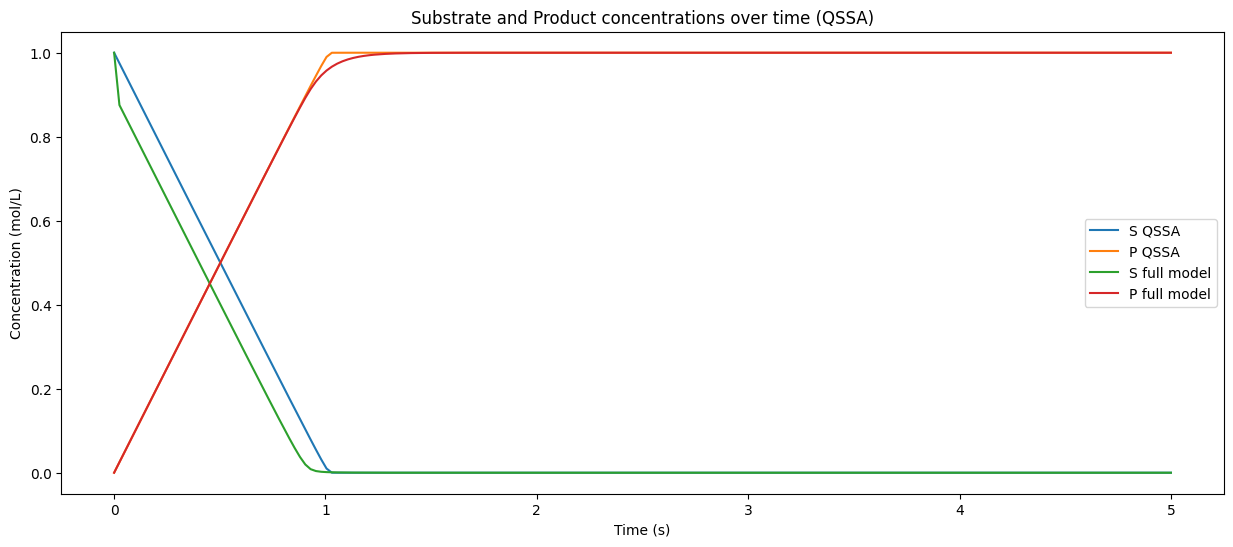

In [ ]:
#Exercice 1 d) Solve the ODE system with QSSA approximation

#parameters
kf = 1e4 #[L.mol-1.s-1]
kb = 20 #[s-1]
kcat = 10 #[s-1]

#QSSA parameters
Km = (kb + kcat) / kf

#initial conditions
E0 = 0.1 #[mol.L-1]
S0 = 1 #[mol.L-1]
ES0 = 0 #[mol.L-1]
P0 = 0 #[mol.L-1]

def qssa(t, y):
    S, P = y
    v = (kcat * E0 * S) / (Km + S)
    dSdt = -v
    dPdt = v
    return [dSdt, dPdt]

solution_qssa = solve_ivp(qssa, t_span, [S0, P0], t_eval=t_eval, method='BDF')
S_qssa, P_qssa = solution_qssa.y
t_qssa = solution_qssa.t

#Conservation check 
SP_sum = S_qssa + P_qssa # This should give 1 as S0 = 1 [mol/L]
print("S+P min/max:", SP_sum.min(), SP_sum.max())

#Plotting the results
plt.figure(figsize=(15, 6))
plt.plot(t_qssa, S_qssa, t_qssa, P_qssa, t, S, t, P)
plt.xlabel("Time (s)")
plt.ylabel("Concentration (mol/L)")
plt.title("Substrate and Product concentrations over time (QSSA)")
plt.legend(["S QSSA", "P QSSA", "S full model", "P full model"])
plt.show()


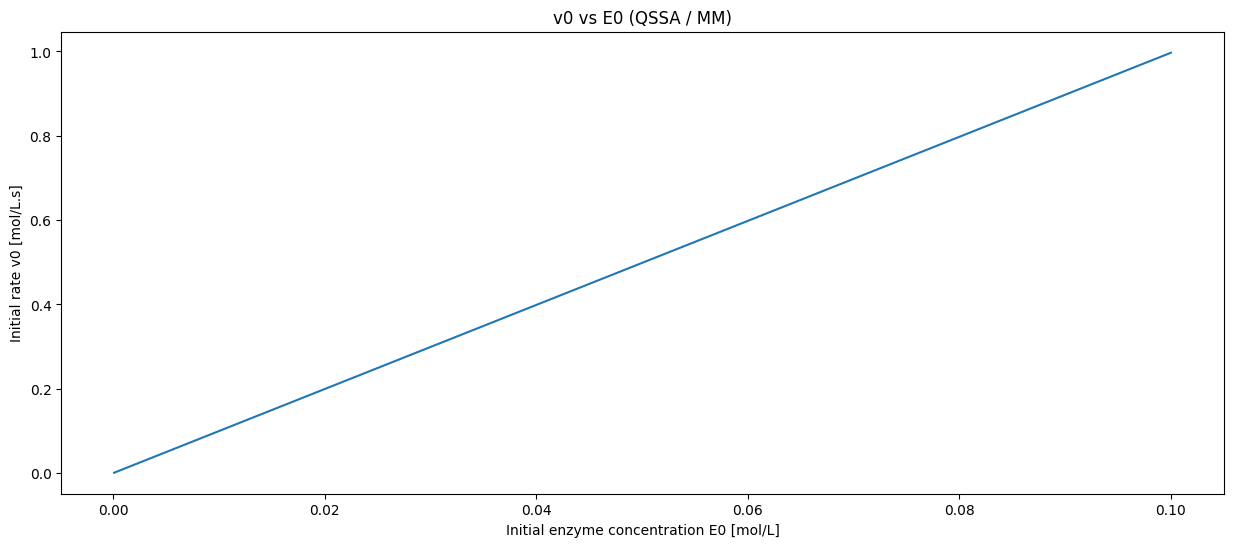

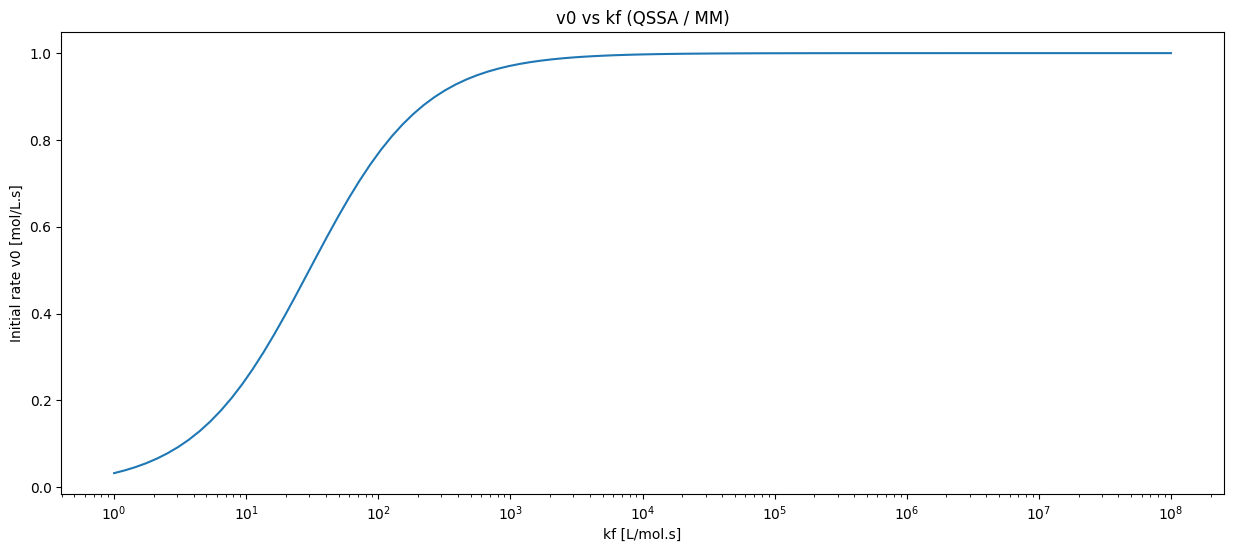

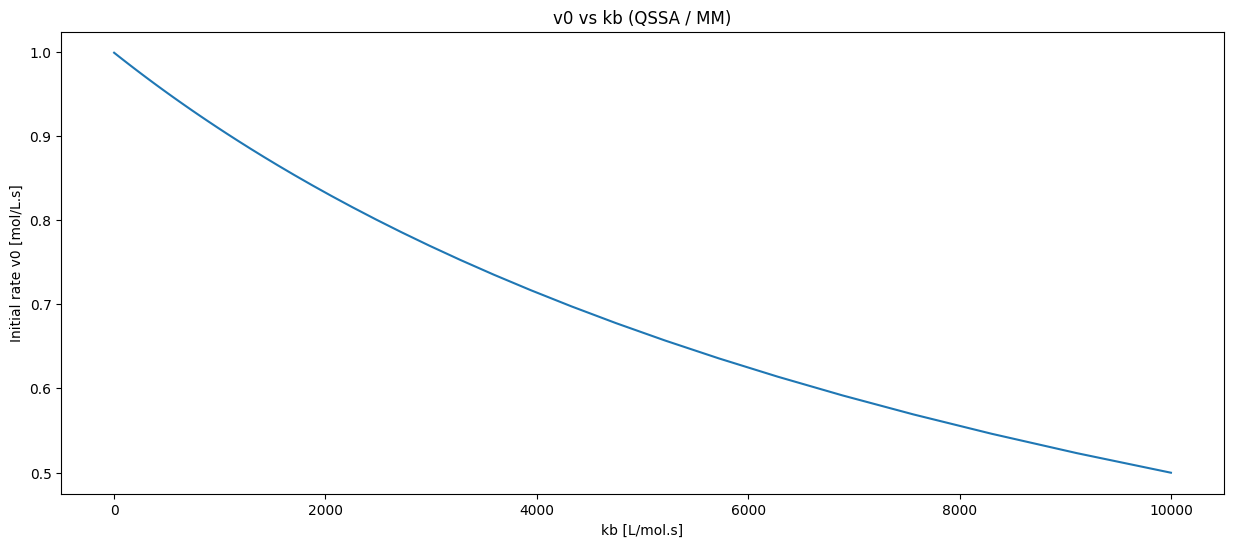

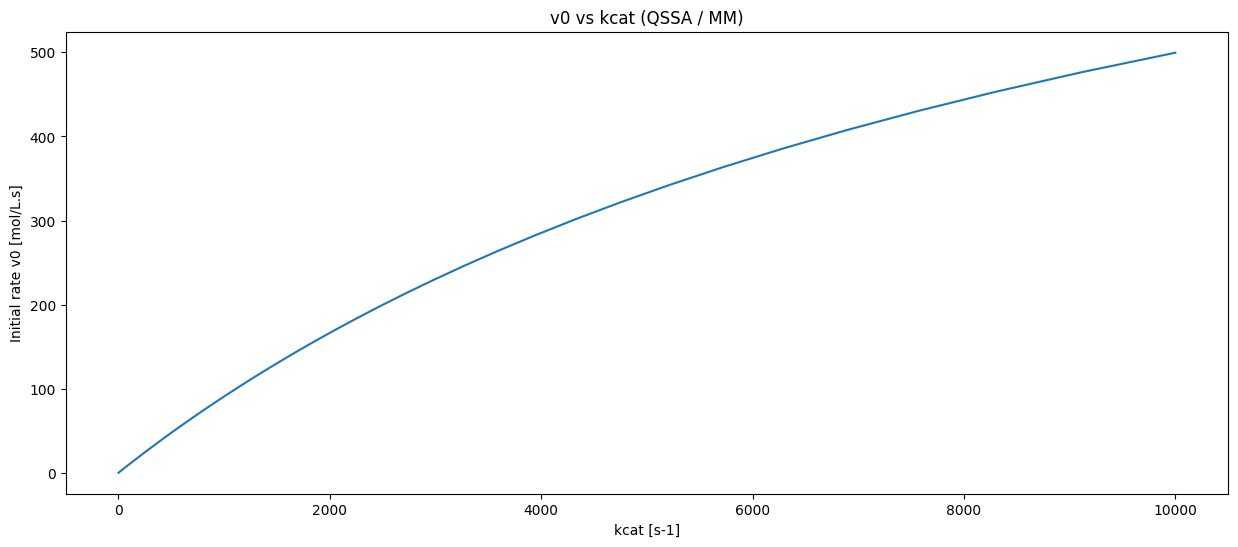

In [ ]:
#Exercice 1 e) Simulations under the QSSA approximation

def v0_mm(S0, E0, kf, kb, kcat):
    Km = (kb + kcat) / kf
    return (kcat * E0 * S0) / (Km + S0)

#1) v0 as a function of E0
E0_range = np.logspace(-4, -1, 100)  # 1e-4 to 1e-1 [mol/L] 
v_E0 = v0_mm(S0, E0_range, kf, kb, kcat)

plt.figure(figsize=(15, 6))
plt.plot(E0_range, v_E0)
plt.xlabel("Initial enzyme concentration E0 [mol/L]")
plt.ylabel("Initial rate v0 [mol/L.s]")
plt.title("v0 vs E0 (QSSA / MM)")
plt.show()

#2) v0 as a function of kf
kf_range = np.logspace(0, 8, 100)  # 1 to 1e8
v_kf = v0_mm(S0, E0, kf_range, kb, kcat)

plt.figure(figsize=(15, 6))
plt.plot(kf_range, v_kf)
plt.xlabel("kf [L/mol.s]") 
plt.ylabel("Initial rate v0 [mol/L.s]")
plt.xscale('log') # Logarithmic scale for better visualization
plt.title("v0 vs kf (QSSA / MM)")
plt.show()

#3) v0 as a function of kb
kb_range = np.logspace(0, 4, 100)  # 1 to 1e4
v_kb = v0_mm(S0, E0, kf, kb_range, kcat)

plt.figure(figsize=(15, 6))
plt.plot(kb_range, v_kb)
plt.xlabel("kb [L/mol.s]")
plt.ylabel("Initial rate v0 [mol/L.s]")
plt.title("v0 vs kb (QSSA / MM)")
plt.show()

#4) v0 as a function of kcat
kcat_range = np.logspace(0, 4, 100)  # 1 to 1e4
v_kcat = v0_mm(S0, E0, kf, kb, kcat_range)

plt.figure(figsize=(15, 6))
plt.plot(kcat_range, v_kcat)
plt.xlabel("kcat [s-1]")
plt.ylabel("Initial rate v0 [mol/L.s]")
plt.title("v0 vs kcat (QSSA / MM)")
plt.show()

## Exercise 1 e) Influence of kinetic parameters on the initial reaction rate

The initial reaction rate under the QSSA is given by the Michaelis–Menten equation:

$$
v_0 = \frac{k_{cat}[E]_0 S_0}{K_M + S_0}
\quad \text{with} \quad
K_M = \frac{k_b + k_{cat}}{k_f}
$$

The influence of each parameter on the initial rate is discussed below.

---

### Influence of the initial enzyme concentration $[E]_0$

The initial rate increases linearly with $[E]_0$.  
Since $V_{max} = k_{cat}[E]_0$, increasing the enzyme concentration proportionally increases the maximum catalytic capacity of the system.  

This confirms that the enzyme acts as a catalyst and directly controls the reaction throughput.

---

### Influence of $k_f$

Increasing $k_f$ decreases the Michaelis constant $K_M$.  
For small $k_f$, $K_M$ is large and the reaction rate is low because the enzyme–substrate complex forms inefficiently.  

As $k_f$ increases, $K_M$ decreases and the rate increases until it reaches a plateau corresponding to:

$$
v_0 \approx k_{cat}[E]_0
$$

This saturation occurs when $K_M \ll S_0$, meaning complex formation is no longer limiting.

---

### Influence of $k_b$

Increasing $k_b$ increases $K_M$, which reduces the reaction rate.  
A large $k_b$ promotes dissociation of the enzyme–substrate complex back to reactants, decreasing the probability of product formation.  

Therefore, the initial rate decreases as $k_b$ increases.

---

### Influence of $k_{cat}$

The parameter $k_{cat}$ directly increases the maximum reaction rate $V_{max} = k_{cat}[E]_0$.  

Although $k_{cat}$ also appears in the expression of $K_M$, its dominant effect is the increase of catalytic turnover.  
As a result, the initial rate increases strongly with increasing $k_{cat}$.

---

### Overall interpretation

The initial reaction rate is most directly controlled by the catalytic efficiency of the enzyme ($k_{cat}$ and $[E]_0$), while substrate binding and dissociation parameters ($k_f$ and $k_b$) influence the rate through their effect on the Michaelis constant $K_M$.

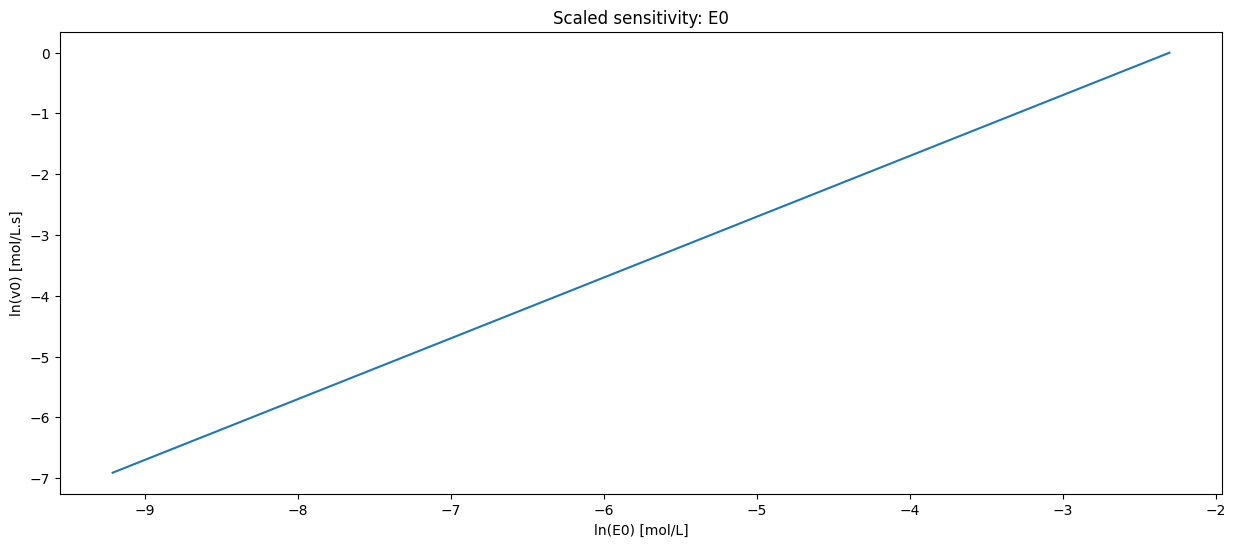

Sensitivity for E0 = 1.0000000000000004


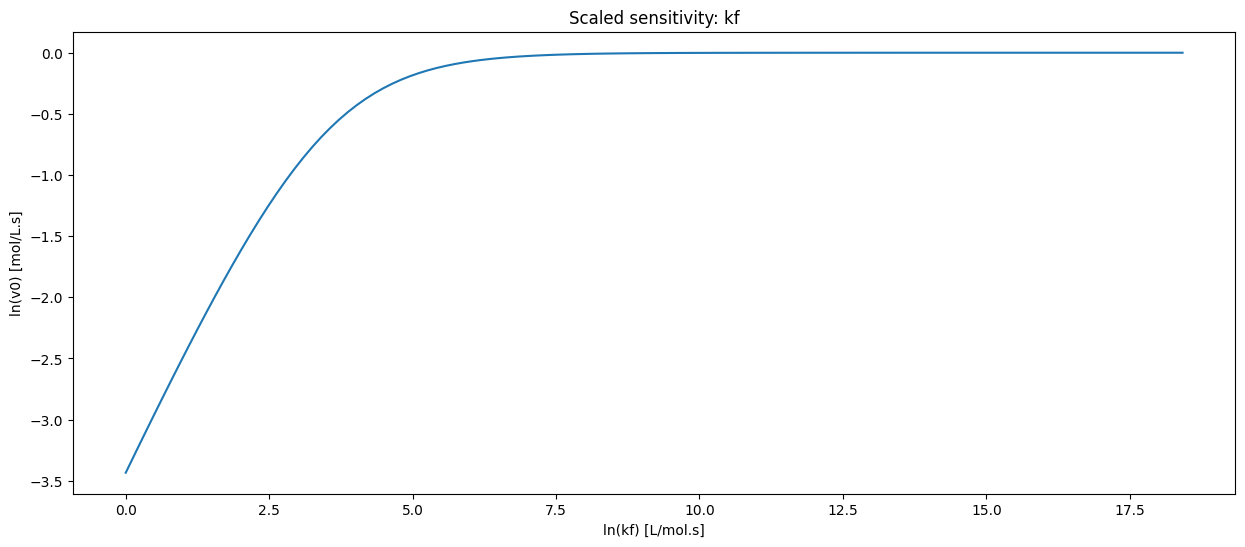

Sensitivity for kf = 0.10935809619605931


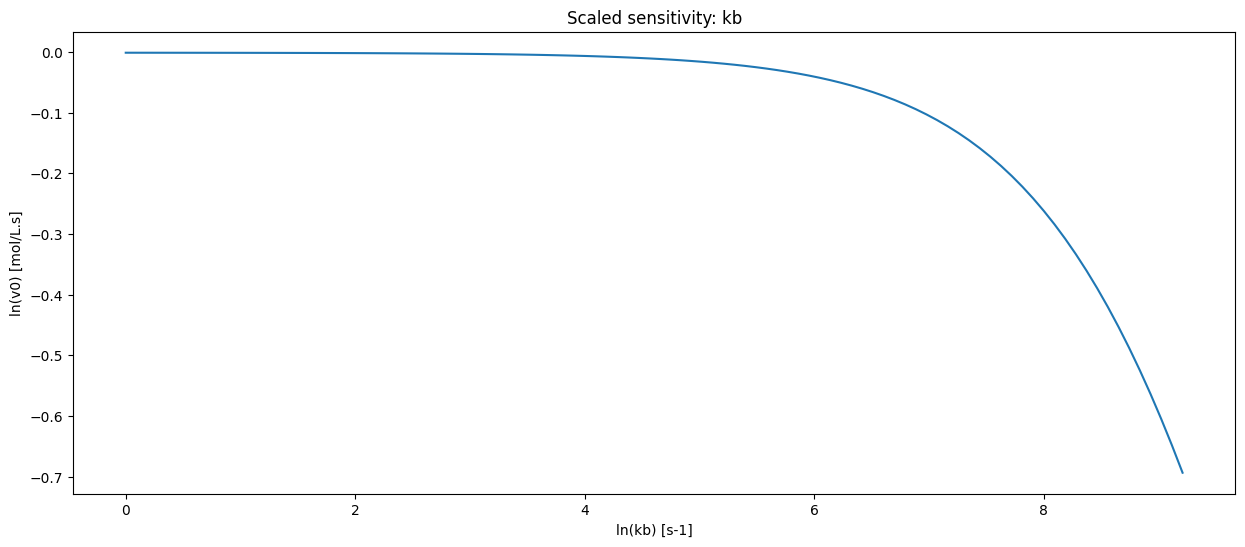

Sensitivity for kb = -0.04523019649319


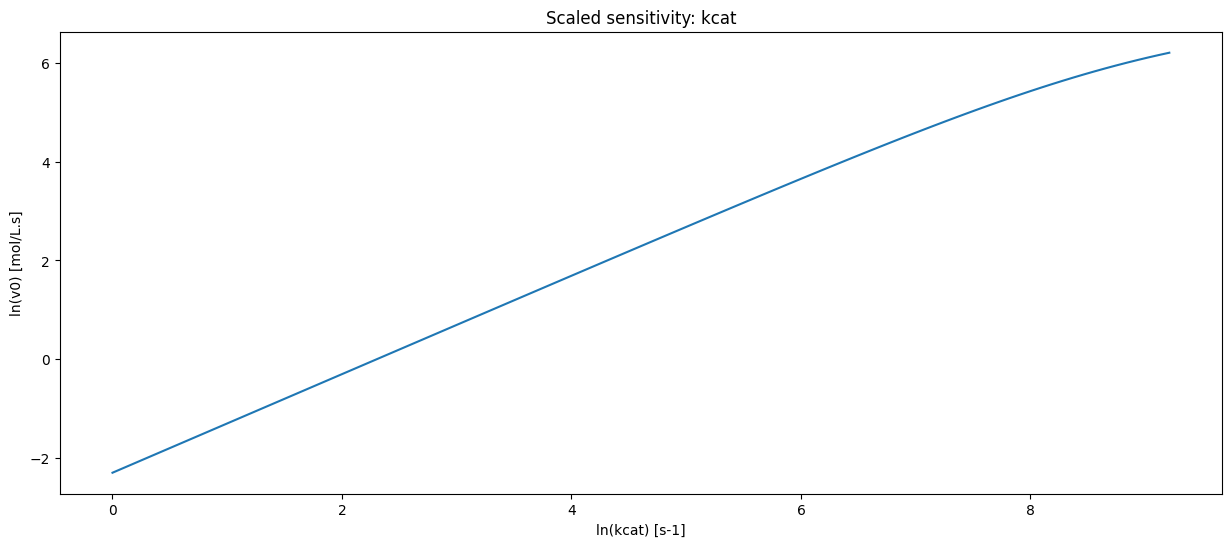

Sensitivity for kcat = 0.9548066496891968


In [50]:
#Exercice 1 f) Identify the most important parameter(s) that determine 𝜈 using scaled sensitivity

#1) ln(v0) as a function of ln(E0)
ln_E0 = np.log(E0_range)
ln_v0 = np.log(v_E0)

plt.figure(figsize=(15, 6))
plt.plot(ln_E0, ln_v0)
plt.xlabel("ln(E0) [mol/L]")
plt.ylabel("ln(v0) [mol/L.s]")
plt.title("Scaled sensitivity: E0")
plt.show()

coeffs = np.polyfit(np.log(E0_range), np.log(v_E0), 1)
slope = coeffs[0]
print("Sensitivity for E0 =", slope)

#2) ln(v0) as a function of ln(kf)
ln_kf = np.log(kf_range)
ln_v0_kf = np.log(v_kf)

plt.figure(figsize=(15, 6))
plt.plot(ln_kf, ln_v0_kf)
plt.xlabel("ln(kf) [L/mol.s]")
plt.ylabel("ln(v0) [mol/L.s]")
plt.title("Scaled sensitivity: kf")
plt.show()

coeffs = np.polyfit(np.log(kf_range), np.log(v_kf), 1)
slope = coeffs[0]
print("Sensitivity for kf =", slope)

#3) ln(v0) as a function of ln(kb)
ln_kb = np.log(kb_range)
ln_v0_kb = np.log(v_kb)

plt.figure(figsize=(15, 6))
plt.plot(ln_kb, ln_v0_kb)
plt.xlabel("ln(kb) [s-1]")
plt.ylabel("ln(v0) [mol/L.s]")
plt.title("Scaled sensitivity: kb")
plt.show()

coeffs = np.polyfit(np.log(kb_range), np.log(v_kb), 1)
slope = coeffs[0]
print("Sensitivity for kb =", slope)

#4) ln(v0) as a function of ln(kcat)
ln_kcat = np.log(kcat_range)
ln_v0_kcat = np.log(v_kcat)

plt.figure(figsize=(15, 6))
plt.plot(ln_kcat, ln_v0_kcat)
plt.xlabel("ln(kcat) [s-1]")
plt.ylabel("ln(v0) [mol/L.s]")
plt.title("Scaled sensitivity: kcat")
plt.show()

coeffs = np.polyfit(np.log(kcat_range), np.log(v_kcat), 1)
slope = coeffs[0]
print("Sensitivity for kcat =", slope)


## Exercise 1 f) Scaled sensitivity analysis

The scaled sensitivity coefficients were obtained from the slope of the plots of 
$\ln(v_0)$ versus $\ln(p)$ for each parameter $p$.

The sensitivity with respect to the initial enzyme concentration $[E]_0$ is equal to 1, 
indicating a strictly proportional relationship between $v_0$ and $[E]_0$. 
This confirms that the maximum reaction rate scales linearly with the enzyme concentration.

The sensitivity with respect to $k_{cat}$ is close to 1, showing that the initial rate 
is strongly controlled by the catalytic turnover number. In the studied regime, the reaction 
operates close to saturation ($S_0 \gg K_M$), so the rate is approximately 
$v_0 \approx k_{cat}[E]_0$, making $k_{cat}$ a dominant parameter.

In contrast, the sensitivities with respect to $k_f$ and $k_b$ are close to zero. 
Although these parameters affect the Michaelis constant $K_M$, their influence becomes weak 
when $K_M \ll S_0$. Under these conditions, substrate binding and dissociation are not 
rate-limiting steps.

Overall, the scaled sensitivity analysis shows that the system is primarily controlled 
by the catalytic efficiency ($k_{cat}$) and the enzyme concentration, while the binding 
parameters ($k_f$, $k_b$) play a minor role in the chosen operating regime.

## Exercise 1 g) Mass balance with two competing products

In this case, the enzyme is not specific and can produce two different products.

### Reaction mechanism

$$
E + S \xrightleftharpoons[k_b]{k_f} ES
$$

$$
ES \xrightarrow{k_{cat,1}} E + P
$$

$$
ES \xrightarrow{k_{cat,2}} E + P_2
$$

The system is analyzed without applying the Quasi-Steady-State Approximation (QSSA).

---

### Elementary reaction rates

The elementary reaction rates are:

$$
r_f = k_f [E][S]
$$

$$
r_b = k_b [ES]
$$

$$
r_{cat,1} = k_{cat,1}[ES]
$$

$$
r_{cat,2} = k_{cat,2}[ES]
$$

---

### Concentration balances (batch reactor, constant volume)

Since the reactor operates at constant volume:

$$
\frac{dC_i}{dt} = r_i
$$

---

### S balance

$$
\frac{d[S]}{dt} = - k_f [E][S] + k_b [ES]
$$

---

### E balance


$$
\frac{d[E]}{dt} =
- k_f [E][S]
+ k_b [ES]
+ k_{cat,1}[ES]
+ k_{cat,2}[ES]
$$

---

### ES balance

$$
\frac{d[ES]}{dt} =
k_f [E][S]
- k_b [ES]
- k_{cat,1}[ES]
- k_{cat,2}[ES]
$$

---

### P balances

$$
\frac{d[P]}{dt} = k_{cat,1}[ES]
$$

$$
\frac{d[P_2]}{dt} = k_{cat,2}[ES]
$$

---

### Conservation of mass

The total enzyme concentration remains constant:

$$
[E]_0 = [E] + [ES]
$$

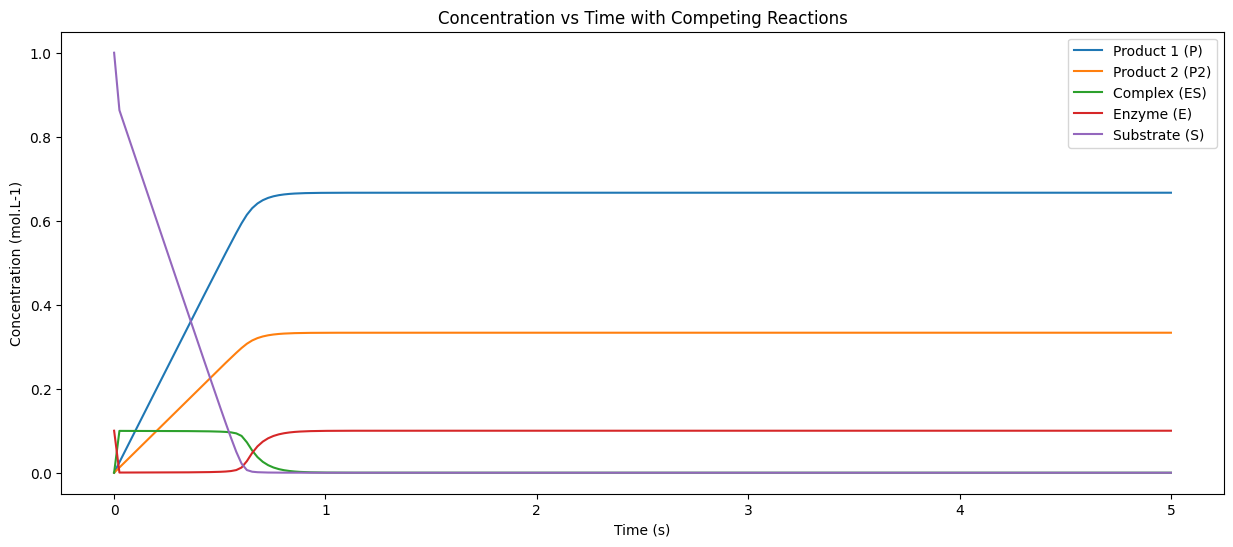

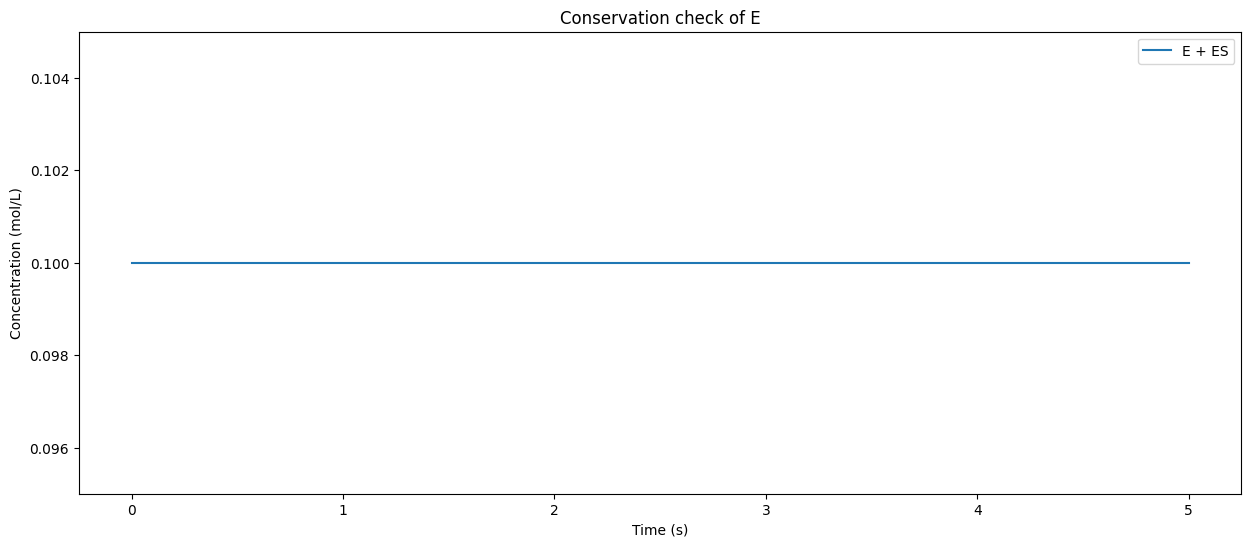

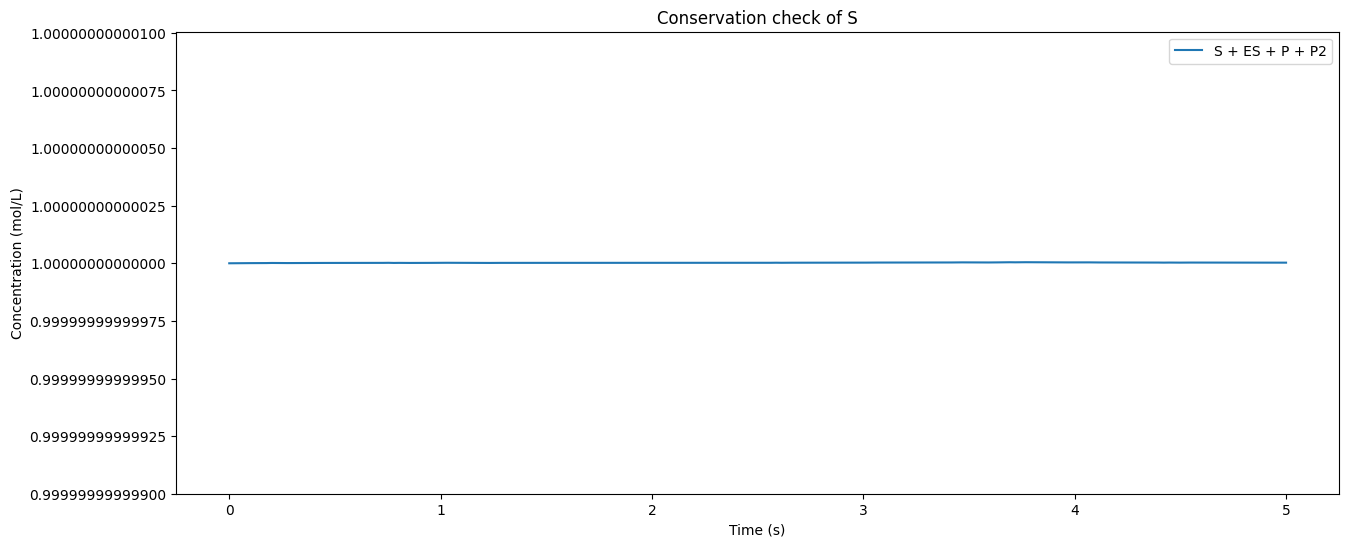

In [51]:
#Exercice 1 h)

#parameters
kf = 1e4 #[L.mol-1.s-1]
kb = 20 #[s-1]
kcat = 10 #[s-1]
kcat2 = 5 #[s-1]

#initial conditions
S0 = 1 #[mol.L-1]
E0 = 0.1 #[mol.L-1]
ES0 = P0 = p20 = 0 #[mol.L-1]

y0 = [S0, E0, ES0, P0, p20]

#Solve the ODE system with competing reactions
def mass_balance_competition(t, y):
    S, E, ES, P, P2 = y
    dSdt = -kf * S * E + kb * ES
    dEdt = -kf * S * E + kb * ES + kcat * ES + kcat2 * ES
    dESdt = kf * S * E - kb * ES - kcat * ES - kcat2 * ES
    dPdt = kcat * ES
    dP2dt = kcat2 * ES
    return [dSdt, dEdt, dESdt, dPdt, dP2dt]

t_span = (0, 5) # from 0 to 5 second
t_eval = np.linspace(0, 5, 200)

solution_competition = solve_ivp(mass_balance_competition, t_span, y0, t_eval=t_eval, method='RK45')
S_competing, E_competing, ES_competing, P_competing, P2_competing = solution_competition.y
t_competing = solution_competition.t

#Mass conservation checks
total_E = E_competing + ES_competing
total_S = S_competing + ES_competing + P_competing + P2_competing

#plotting the results
plt.figure(figsize=(15, 6))
plt.plot(t_competing, P_competing, t_competing, P2_competing, t_competing, ES_competing, t_competing, E_competing, t_competing, S_competing)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol.L-1)')
plt.legend(['Product 1 (P)', 'Product 2 (P2)', 'Complex (ES)', 'Enzyme (E)', 'Substrate (S)'])
plt.title('Concentration vs Time with Competing Reactions')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(t_competing, total_E, label="E + ES")
plt.xlabel("Time (s)")
plt.ylabel("Concentration (mol/L)")
plt.title("Conservation check of E")
plt.ylim(0.095, 0.105)
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(t_competing, total_S, label="S + ES + P + P2")
plt.xlabel("Time (s)")
plt.ylabel("Concentration (mol/L)")
plt.title("Conservation check of S")
plt.legend()
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.show()

## Exercise 1 i) Selectivity analysis

The selectivity toward product P over P₂ is determined by the ratio of their formation rates:

$$
\frac{dP/dt}{dP_2/dt} = \frac{k_{cat,1}}{k_{cat,2}}
$$

Since both products originate from the same enzyme–substrate complex (ES), the selectivity depends only on the ratio of the catalytic rate constants.

Therefore, to increase the selectivity toward P, one must increase $k_{cat,1}$ or decrease $k_{cat,2}$. 

Parameters related to substrate binding and dissociation ($k_f$ and $k_b$) do not influence selectivity, as they affect the overall reaction rate but not the competition between the two catalytic pathways.